# Figure S2 ALFA tag DASIT

In [41]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.ticker import ScalarFormatter
from pathlib import Path
import scipy
import seaborn as sns
from statannotations.Annotator import Annotator
import rushd as rd
import matplotlib
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.optimize import fsolve

# MOI calculation for Lenti - TagBFPxALFA x1 or x3 - WPRE

Notes:
1. Singlets
2. Lentivirus infection in suspension, 20k/96-well with polybrene
3. 4 dpi

## Load data

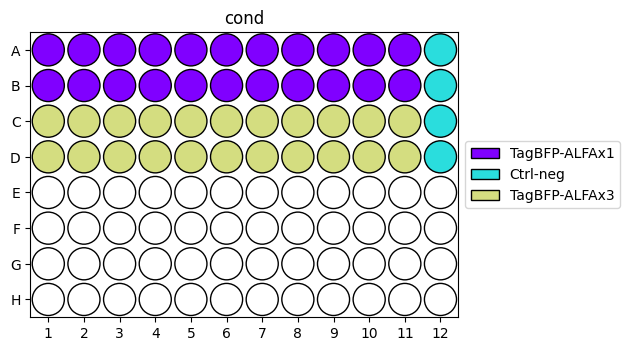

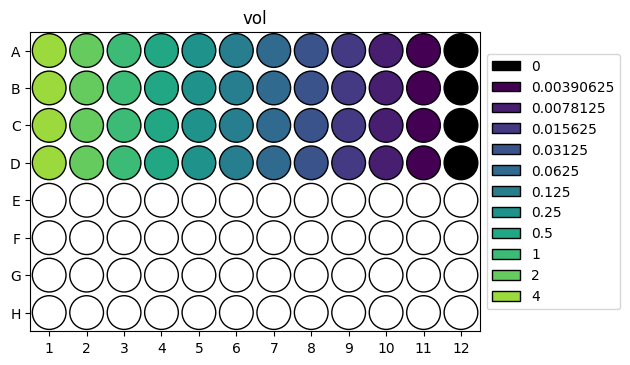

In [2]:
# Directories
figpath = './figures/2025.07.07_293T_DASIT-test_4dpi/MOI/'
base_datadir = rd.datadir / "nat_attune" / "desNb-circuits"  / "2025.07.07_293T_DASIT-test_4dpi" / 'export'
# base_datadir = Path("/Users/natwang/Downloads/2025.07.07_293T_DASIT-test_4dpi")

# Load data 
datadir = base_datadir/'MOI'
df_MOI_all = rd.flow.load_csv_with_metadata(datadir, datadir/'MOI_metadata.yaml')
rd.plot.plot_well_metadata(datadir/ 'MOI_metadata.yaml')

# Get rid of negative data
df_MOI = df_MOI_all.loc[( df_MOI_all["TagBFP-A"] > 0) & (df_MOI_all["mRuby2-A"] > 0)]

## Test out MOI distributions

At MOI: 0.15, expect 13.9% infected


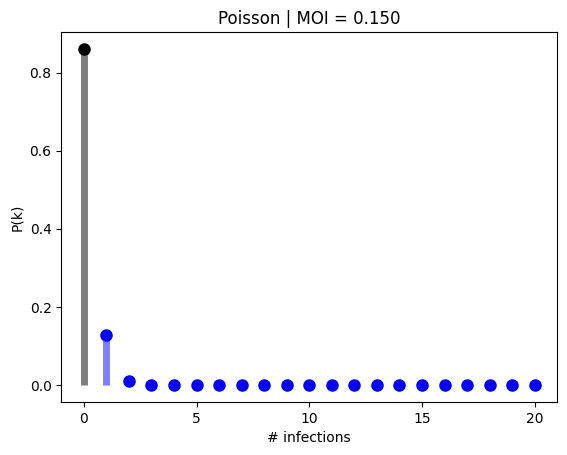

In [101]:
# MOI = TUratio*virus_vol
MOI_list = [0.15]

for m in MOI_list:
    # k = np.arange(poisson.ppf(0.01, m),
    #             poisson.ppf(0.99, m))
    k = np.arange(0, 21)

    fig, ax = plt.subplots(1, 1)
    ax.plot(k[1:], poisson.pmf(k[1:], m), 'bo', ms=8, label='Poisson pmf')
    ax.vlines(k[1:], 0, poisson.pmf(k[1:], m), colors='b', lw=5, alpha=0.5)

    ax.plot(k[0], poisson.pmf([0], m), 'ko', ms=8, label='No infect')
    ax.vlines(k[0], 0, poisson.pmf(k[0], m), colors='k', lw=5, alpha=0.5)

    # plt.axvline(0.5, color='k', linestyle='--')

    ax.set_xticks(np.arange(0, 21, 5))
    ax.set_ylabel('P(k)')
    ax.set_xlabel('# infections')
    plt.title(f'Poisson | MOI = {m:.3f}')
    # plt.savefig(figpath +f'Poisson_pmf_{m:.3f}.svg', bbox_inches='tight')

    Infected = (1-np.exp(-m))*100
    print(f'At MOI: {m}, expect {Infected:.1f}% infected')


## MOI calc from 7/7/2025

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_12886/537873677.py:44: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  sub_ax.set_xlim(TagBFP_lim)


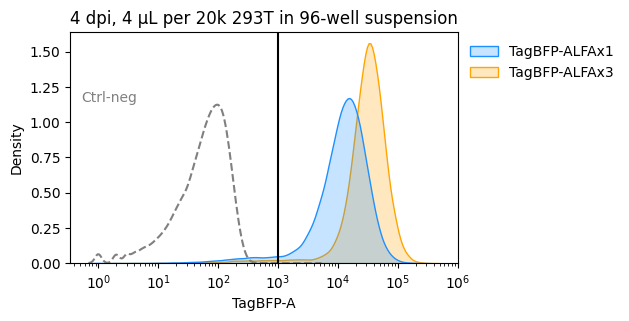

In [38]:
# Threshold for TagBFP
TagBFP_A_thresh = 1*10**3

# Plot parameters
x = 'TagBFP-A'
hue = 'cond'
hue_order = ['TagBFP-ALFAx3', 'TagBFP-ALFAx1']
palette = {
    'TagBFP-ALFAx3': 'orange',
    'TagBFP-ALFAx1': 'dodgerblue',
}


fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sns.kdeplot(
    data=df_MOI.loc[(df_MOI['vol'] == 4)],
    hue=hue,
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False), palette=palette,
    fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_MOI.loc[(df_MOI['cond'] == 'Ctrl-neg')],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(TagBFP_A_thresh, 0, 1, color='black')

# Move legend outside
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h, labels=l,
    title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Title
plt.title('4 dpi, 4 µL per 20k 293T in 96-well suspension')
# Adjust limits
TagBFP_lim = (0, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(TagBFP_lim)

# Save fig
# plt.savefig(figpath + 'dist-TagBFP-both_vol-4.svg', bbox_inches='tight')

Calculate TagBFP% + 

In [62]:
# Categorize cells based on TagBFP
df_MOI['TagBFP_cat'] = np.where(df_MOI['TagBFP-A'] > TagBFP_A_thresh, 'TagBFP+', 'TagBFP-') 

# Get total counts and percent of TagBFP-A+
group = ['cond', 'vol']
count_df_reps = df_MOI.groupby([*group, 'well', 'TagBFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no TagBFP-A+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='TagBFP+ percent')

# Take only TagBFP+ cells
df_TagBFP_percent = percent_df_reps.loc[percent_df_reps.TagBFP_cat == 'TagBFP+']
df_TagBFP_percent['TagBFP+ frac'] = df_TagBFP_percent['TagBFP+ percent']/100


/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_12886/3744990081.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_MOI['TagBFP_cat'] = np.where(df_MOI['TagBFP-A'] > TagBFP_A_thresh, 'TagBFP+', 'TagBFP-')
/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_12886/3744990081.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_TagBFP_percent['TagBFP+ frac'] = df_TagBFP_percent['TagBFP+ percent']/100


### MOI for TagBFP-ALFAx3

To get an MOI = 0.15
	cond: TagBFP-ALFAx3
	TU: 21.04 TU/µL at 20k 293T in suspension
	vol: 0.00713 µL/well at 20k 293T in suspension
Estimated MOI at vol = 4
	cond: TagBFP-ALFAx3
	MOI: 84.2 at 20k 293T in suspension


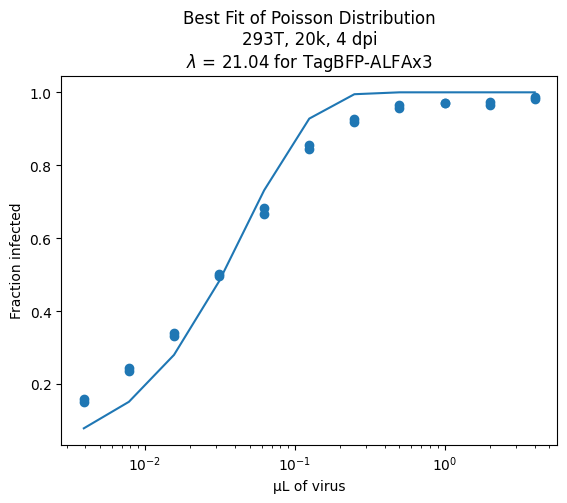

In [63]:
cond = 'TagBFP-ALFAx3'
df_TagBFP_pecent_ALFAx3 = df_TagBFP_percent[df_TagBFP_percent.cond == cond]


def poisson_model(virus_vol, TUratio):
    # MOI = TUratio*virus_vol
    return 1 - np.exp(-TUratio * virus_vol)

popt, _ = curve_fit(
    poisson_model,
    df_TagBFP_pecent_ALFAx3["vol"],
    df_TagBFP_pecent_ALFAx3["TagBFP+ frac"],
    p0=0.5,
    bounds=(0, np.inf),
)

df = df_TagBFP_pecent_ALFAx3.sort_values("vol")
plt.scatter(df["vol"], df["TagBFP+ frac"])
plt.plot(df["vol"], poisson_model(df["vol"], *popt))

plt.title(f"Best Fit of Poisson Distribution\n293T, 20k, 4 dpi\n$\lambda$ = {popt[0]:.2f} for {cond}")
plt.xscale("log")
plt.ylabel("Fraction infected")
plt.xlabel("µL of virus")
# plt.savefig(figpath + f'MOI-fit_{cond}.svg', bbox_inches='tight')

# For MOI 
MOI_desired = 0.15
print(f'To get an MOI = {MOI_desired}')
print(f'\tcond: {cond}')
print(f'\tTU: {popt[0]:.2f} TU/µL at 20k 293T in suspension')
print(f'\tvol: {MOI_desired/popt[0]:.5f} µL/well at 20k 293T in suspension')
vol = 4
print(f'Estimated MOI at vol = {vol}')
print(f'\tcond: {cond}')
print(f'\tMOI: {popt[0]*vol:.1f} at 20k 293T in suspension')



### MOI for TagBFP-ALFAx1

To get an MOI = 0.15
	cond: TagBFP-ALFAx1
	TU: 3.53 TU/µL at 20k 293T in suspension
	vol: 0.04249 µL/well at 20k 293T in suspension
Estimated MOI at vol = 4
	cond: TagBFP-ALFAx1
	MOI: 14.1 at 20k 293T in suspension


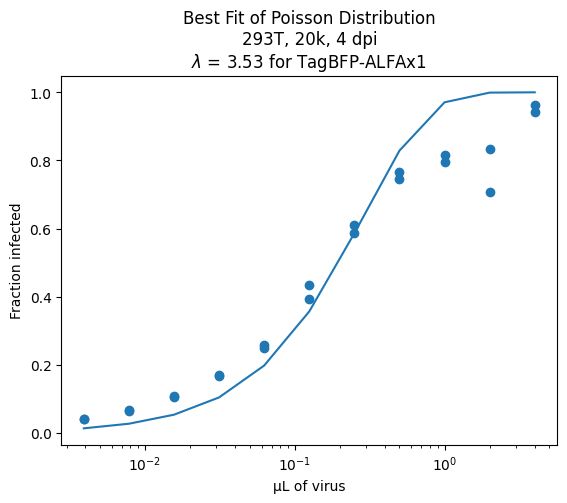

In [35]:
cond = 'TagBFP-ALFAx1'
df_TagBFP_pecent_ALFAx1 = df_TagBFP_percent[df_TagBFP_percent.cond == cond]


def poisson_model(virus_vol, TUratio):
    # MOI = TUratio*virus_vol
    return 1 - np.exp(-TUratio * virus_vol)

popt, _ = curve_fit(
    poisson_model,
    df_TagBFP_pecent_ALFAx1["vol"],
    df_TagBFP_pecent_ALFAx1["TagBFP+ frac"],
    p0=0.5,
    bounds=(0, np.inf),
)

df = df_TagBFP_pecent_ALFAx1.sort_values("vol")
plt.scatter(df["vol"], df["TagBFP+ frac"])
plt.plot(df["vol"], poisson_model(df["vol"], *popt))

plt.title(f"Best Fit of Poisson Distribution\n293T, 20k, 4 dpi\n$\lambda$ = {popt[0]:.2f} for {cond}")
plt.xscale("log")
plt.ylabel("Fraction infected")
plt.xlabel("µL of virus")
# plt.savefig(figpath + f'MOI-fit_{cond}.svg', bbox_inches='tight')

# For MOI 
MOI_desired = 0.15
print(f'To get an MOI = {MOI_desired}')
print(f'\tcond: {cond}')
print(f'\tTU: {popt[0]:.2f} TU/µL at 20k 293T in suspension')
print(f'\tvol: {MOI_desired/popt[0]:.5f} µL/well at 20k 293T in suspension')
vol = 4
print(f'Estimated MOI at vol = {vol}')
print(f'\tcond: {cond}')
print(f'\tMOI: {popt[0]*vol:.1f} at 20k 293T in suspension')

## What if don't exclude neg fluorescence

Calc using all cells

In [ ]:
# Categorize cells based on TagBFP
df_MOI_all.loc[:, 'TagBFP_cat'] = 'TagBFP-'
df_MOI_all.loc[(df_MOI_all['TagBFP-A'] > TagBFP_A_thresh), 'TagBFP_cat'] = 'TagBFP+'

# Get total counts and percent of TagBFP-A+
group = ['cond', 'vol']
count_df_reps = df_MOI_all.groupby([*group, 'well', 'TagBFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no TagBFP-A+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='TagBFP+ percent')

# Take only TagBFP+ cells
df_TagBFP_percent_all = percent_df_reps.loc[percent_df_reps.TagBFP_cat == 'TagBFP+']
df_TagBFP_percent_all['TagBFP+ frac'] = df_TagBFP_percent_all['TagBFP+ percent']/100


To get an MOI = 0.15
	cond: TagBFP-ALFAx3
	TU: 11.38 TU/µL at 20k 293T in suspension
	vol: 0.01319 µL/well at 20k 293T in suspension


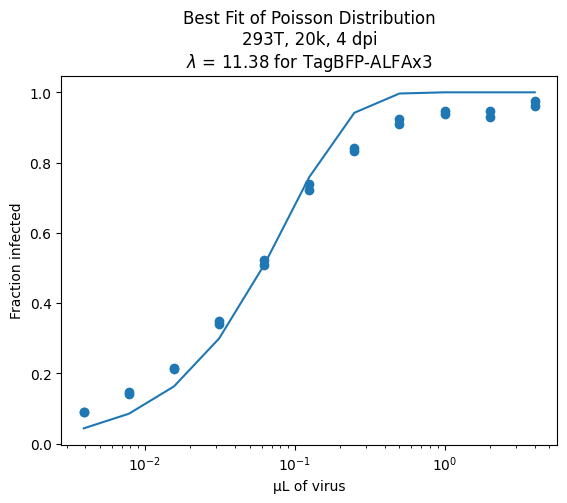

In [17]:
cond = 'TagBFP-ALFAx3'
df_TagBFP_pecent_ALFAx3 = df_TagBFP_percent_all[df_TagBFP_percent_all.cond == cond]


def poisson_model(virus_vol, TUratio):
    # MOI = TUratio*virus_vol
    return 1 - np.exp(-TUratio * virus_vol)

popt, _ = curve_fit(
    poisson_model,
    df_TagBFP_pecent_ALFAx3["vol"],
    df_TagBFP_pecent_ALFAx3["TagBFP+ frac"],
    p0=0.5,
    bounds=(0, np.inf),
)

df = df_TagBFP_pecent_ALFAx3.sort_values("vol")
plt.scatter(df["vol"], df["TagBFP+ frac"])
plt.plot(df["vol"], poisson_model(df["vol"], *popt))

plt.title(f"Best Fit of Poisson Distribution\n293T, 20k, 4 dpi\n$\lambda$ = {popt[0]:.2f} for {cond}")
plt.xscale("log")
plt.ylabel("Fraction infected")
plt.xlabel("µL of virus")
# plt.savefig(figpath + f'MOI-fit-all_{cond}.svg', bbox_inches='tight')

# For MOI 
MOI_desired = 0.15
print(f'To get an MOI = {MOI_desired}')
print(f'\tcond: {cond}')
print(f'\tTU: {popt[0]:.2f} TU/µL at 20k 293T in suspension')
print(f'\tvol: {MOI_desired/popt[0]:.5f} µL/well at 20k 293T in suspension')


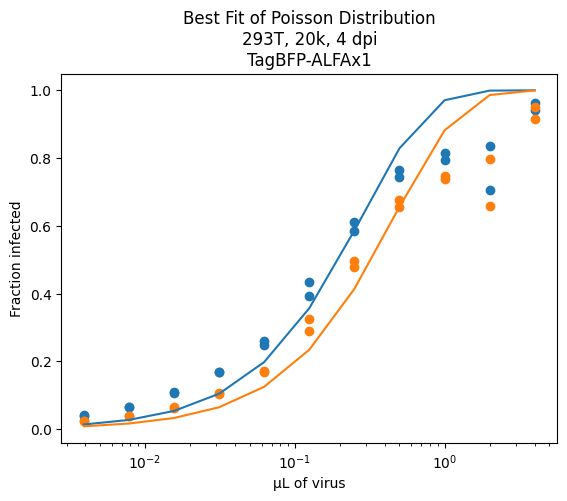

In [24]:
cond = 'TagBFP-ALFAx1'
df_TagBFP_pecent_ALFAx1 = df_TagBFP_percent[df_TagBFP_percent.cond == cond]
df_TagBFP_pecent_ALFAx1_all = df_TagBFP_percent_all[df_TagBFP_percent_all.cond == cond]


def poisson_model(virus_vol, TUratio):
    # MOI = TUratio*virus_vol
    return 1 - np.exp(-TUratio * virus_vol)

popt, _ = curve_fit(
    poisson_model,
    df_TagBFP_pecent_ALFAx1["vol"],
    df_TagBFP_pecent_ALFAx1["TagBFP+ frac"],
    p0=0.5,
    bounds=(0, np.inf),
)

popt_all, _ = curve_fit(
    poisson_model,
    df_TagBFP_pecent_ALFAx1_all["vol"],
    df_TagBFP_pecent_ALFAx1_all["TagBFP+ frac"],
    p0=0.5,
    bounds=(0, np.inf),
)

df_results = df_TagBFP_pecent_ALFAx1.sort_values("vol")
df_result_all = df_TagBFP_pecent_ALFAx1_all.sort_values("vol")

plt.scatter(df_results["vol"], df_results["TagBFP+ frac"])
plt.plot(df_results["vol"], poisson_model(df_results["vol"], *popt))

plt.scatter(df_result_all["vol"], df_result_all["TagBFP+ frac"])
plt.plot(df_result_all["vol"], poisson_model(df_result_all["vol"], *popt_all))

plt.title(f"Best Fit of Poisson Distribution\n293T, 20k, 4 dpi\n{cond}")
plt.xscale("log")
plt.ylabel("Fraction infected")
plt.xlabel("µL of virus")
# plt.savefig(figpath + f'MOI-fit-both_{cond}.svg', bbox_inches='tight')

Plot both on same

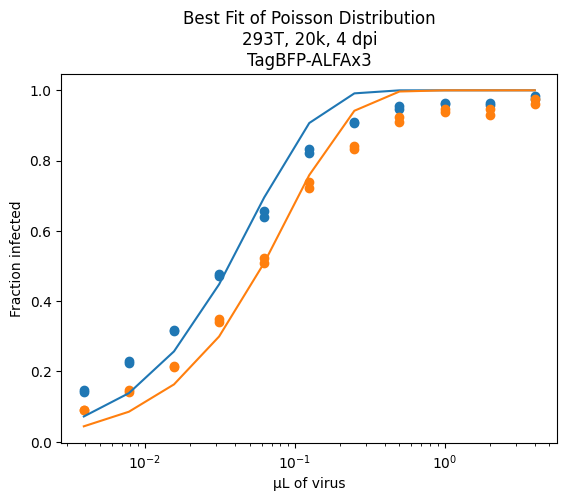

In [23]:
cond = 'TagBFP-ALFAx3'
df_TagBFP_pecent_ALFAx3 = df_TagBFP_percent[df_TagBFP_percent.cond == cond]
df_TagBFP_pecent_ALFAx3_all = df_TagBFP_percent_all[df_TagBFP_percent_all.cond == cond]


def poisson_model(virus_vol, TUratio):
    # MOI = TUratio*virus_vol
    return 1 - np.exp(-TUratio * virus_vol)

popt, _ = curve_fit(
    poisson_model,
    df_TagBFP_pecent_ALFAx3["vol"],
    df_TagBFP_pecent_ALFAx3["TagBFP+ frac"],
    p0=0.5,
    bounds=(0, np.inf),
)

popt_all, _ = curve_fit(
    poisson_model,
    df_TagBFP_pecent_ALFAx3_all["vol"],
    df_TagBFP_pecent_ALFAx3_all["TagBFP+ frac"],
    p0=0.5,
    bounds=(0, np.inf),
)

df_results = df_TagBFP_pecent_ALFAx3.sort_values("vol")
df_result_all = df_TagBFP_pecent_ALFAx3_all.sort_values("vol")

plt.scatter(df_results["vol"], df_results["TagBFP+ frac"])
plt.plot(df_results["vol"], poisson_model(df_results["vol"], *popt))

plt.scatter(df_result_all["vol"], df_result_all["TagBFP+ frac"])
plt.plot(df_result_all["vol"], poisson_model(df_result_all["vol"], *popt_all))

plt.title(f"Best Fit of Poisson Distribution\n293T, 20k, 4 dpi\n{cond}")
plt.xscale("log")
plt.ylabel("Fraction infected")
plt.xlabel("µL of virus")
# plt.savefig(figpath + f'MOI-fit-both_{cond}.svg', bbox_inches='tight')



## Is the fluorescence different?

In [28]:
# Grab most low MOI population
min_vol = np.min(df_TagBFP_pecent_ALFAx3.vol.unique())
df_MOI_low = df_MOI.loc[df_MOI.vol == min_vol]

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_12886/1666224334.py:44: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  sub_ax.set_xlim(TagBFP_lim)


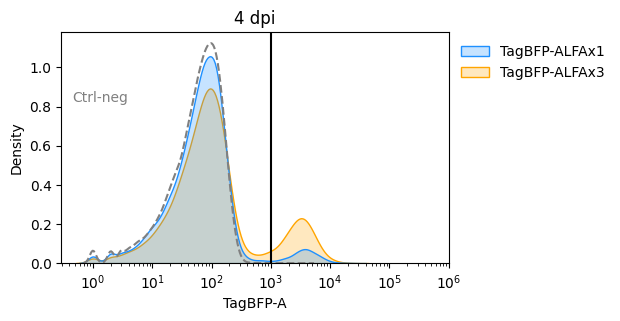

In [36]:
# Threshold for TagBFP
TagBFP_A_thresh = 1*10**3

# Plot parameters
x = 'TagBFP-A'
hue = 'cond'
hue_order = ['TagBFP-ALFAx3', 'TagBFP-ALFAx1']
palette = {
    'TagBFP-ALFAx3': 'orange',
    'TagBFP-ALFAx1': 'dodgerblue',
}


fig, ax = plt.subplots(1, 1, figsize=(5, 3))
sns.kdeplot(
    data=df_MOI_low,
    hue=hue,
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False), palette=palette,
    fill=True)

# Plot neg ctrl
sns.kdeplot(
    data=df_MOI.loc[(df_MOI['cond'] == 'Ctrl-neg')],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
ax.axvline(TagBFP_A_thresh, 0, 1, color='black')

# Move legend outside
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h, labels=l,
    title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)


# Title
plt.title('4 dpi')
# Adjust limits
TagBFP_lim = (0, 1*10**6)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(TagBFP_lim)

# Save fig
# plt.savefig(figpath + f'dist-TagBFP-both_vol-{min_vol}.svg', bbox_inches='tight')

### Compare gmean expression

In [50]:
# Calc gmean
x = 'TagBFP-A'

# Add in ctrl neg
df = df_MOI_low.copy()
df = pd.concat([df, df_MOI.loc[(df_MOI['cond'] == 'Ctrl-neg')] ])

# Well grouping
group = ['cond', 'vol', 'well', 'TagBFP_cat']
df_MOI_low_gmean = df.groupby(group)[x].apply(scipy.stats.gmean).reset_index(name=x+' (gmean)')
# Get rid of false TagBFP+ in Ctrl-neg
df_MOI_low_gmean = df_MOI_low_gmean.loc[~((df_MOI_low_gmean.cond == 'Ctrl-neg') & (df_MOI_low_gmean.TagBFP_cat == 'TagBFP+'))]
df_MOI_low_gmean

,cond,vol,well,TagBFP_cat,TagBFP-A (gmean)
0,Ctrl-neg,0.000000,A12,TagBFP-,50.687827
1,Ctrl-neg,0.000000,B12,TagBFP-,51.550641
3,Ctrl-neg,0.000000,C12,TagBFP-,53.409043
5,Ctrl-neg,0.000000,D12,TagBFP-,52.538325
6,TagBFP-ALFAx1,0.003906,A11,TagBFP+,3655.626147
7,TagBFP-ALFAx1,0.003906,A11,TagBFP-,54.508803
8,TagBFP-ALFAx1,0.003906,B11,TagBFP+,3637.283452
9,TagBFP-ALFAx1,0.003906,B11,TagBFP-,54.430307
10,TagBFP-ALFAx3,0.003906,C11,TagBFP+,3158.009096
11,TagBFP-ALFAx3,0.003906,C11,TagBFP-,62.371803


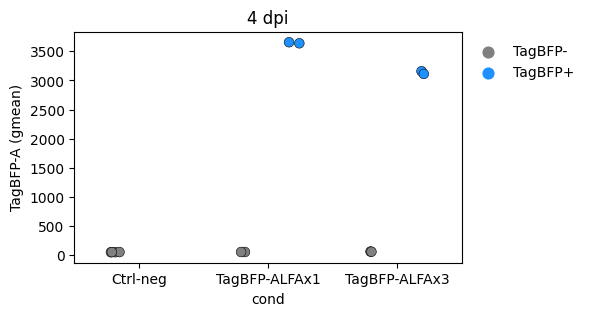

In [54]:
# Plotting params
x = 'cond'
y = 'TagBFP-A'
hue = 'TagBFP_cat'

# Conditions
order =  ['Ctrl-neg', 'TagBFP-ALFAx1', 'TagBFP-ALFAx3']
hue_order = ['TagBFP-', 'TagBFP+']
palette = {'TagBFP-': 'grey','TagBFP+': 'dodgerblue'}

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

# Plot well geometric means
sns.stripplot(
    ax=ax, data=df_MOI_low_gmean, hue=hue,
    x=x, y=y+' (gmean)',
    order=order, hue_order=hue_order,
    dodge=True, 
    size=7, palette=palette,
    edgecolor='black', linewidth=0.4,)

# Adjust labels
# ax.yaxis.set_label_text('eGFP\n(gmean)')
sns.move_legend(ax, title="", loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
plt.title('4 dpi')
# plt.savefig(figpath + 'stripplt-TagBFP.svg', bbox_inches='tight')

# Nb(ALFA) results

Notes:
1. Singlets
2. Lentivirus infection in suspension, 20k/96-well with polybrene
3. 4 dpi

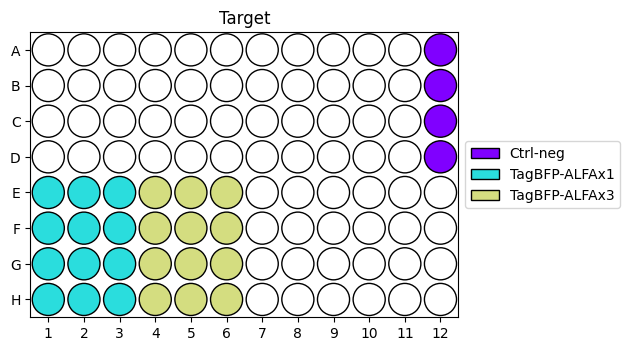

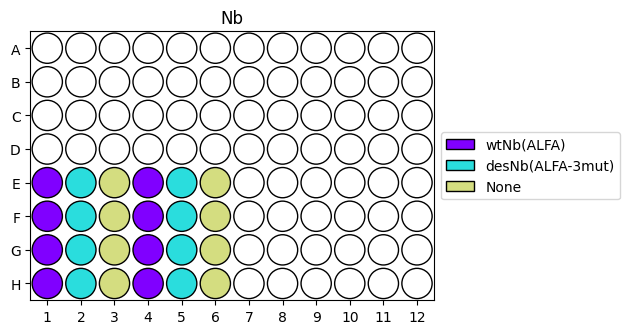

In [66]:
# Directories
figpath = './figures/2025.07.07_293T_DASIT-test_4dpi/test/'
base_datadir = rd.datadir / "nat_attune" / "desNb-circuits"  / "2025.07.07_293T_DASIT-test_4dpi" / 'export'

# Load data 
datadir = base_datadir/'test'
df = rd.flow.load_csv_with_metadata(datadir, datadir/'test_metadata.yaml')
rd.plot.plot_well_metadata(datadir/ 'test_metadata.yaml')

# Get rid of negative data
df = df.loc[( df["TagBFP-A"] > 0) & (df["mRuby2-A"] > 0)]

## Look at basic distributions

### Histograms

(1, 1000000)

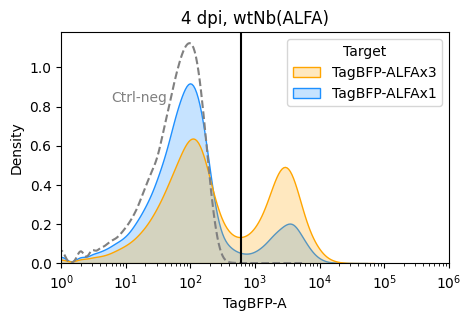

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))


# Plot TagBFP-A
x = 'TagBFP-A'
hue = 'Target'
hue_order = ['TagBFP-ALFAx3', 'TagBFP-ALFAx1']
palette = {
    'TagBFP-ALFAx3': 'orange',
    'TagBFP-ALFAx1': 'dodgerblue',
}

# Just look at wtNb
Nb = 'wtNb(ALFA)'
small_data = df[df.Nb == Nb]

# Plot data
sns.kdeplot(
    data=small_data, ax=ax, x=x, hue=hue,
    hue_order=hue_order, 
    common_norm=False, log_scale=(True, False),
    fill=True, palette=palette)

# Plot neg ctrl
sns.kdeplot(
    data=df.loc[(df['Target'] == 'Ctrl-neg')],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.2, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
TagBFP_A_thresh = 6e2
ax.axvline(TagBFP_A_thresh, 0, 1, color='black')

# Title
plt.title(f'4 dpi, {Nb}')
# Adjust limits
TagBFP_lim = (1, 1*10**6)
ax.set_xlim(TagBFP_lim)
# plt.savefig(figpath + f'dist-TagBFP_{Nb}.svg', bbox_inches='tight')

(1, 1000000)

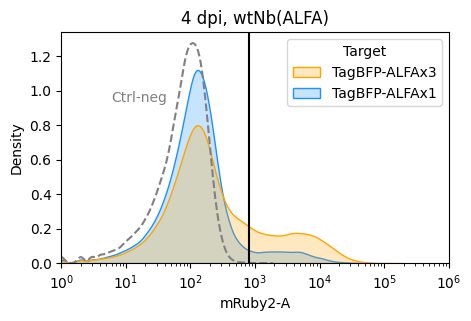

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))


# Plot mRuby2-A
x = 'mRuby2-A'
hue = 'Target'
hue_order = ['TagBFP-ALFAx3', 'TagBFP-ALFAx1']
palette = {
    'TagBFP-ALFAx3': 'orange',
    'TagBFP-ALFAx1': 'dodgerblue',
}

# Just look at wtNb
Nb = 'wtNb(ALFA)'
small_data = df[df.Nb == Nb]

# Plot data
sns.kdeplot(
    data=small_data, ax=ax, x=x, hue=hue,
    hue_order=hue_order, 
    common_norm=False, log_scale=(True, False),
    fill=True, palette=palette)

# Plot neg ctrl
sns.kdeplot(
    data=df.loc[(df['Target'] == 'Ctrl-neg')],
    ax=ax, x=x,
    common_norm=False, log_scale=(True, False),
    fill=False, linestyle='--', color='grey')
ax.annotate('Ctrl-neg', (0.2, 0.7), color='grey', xycoords='axes fraction', ha='center')

# Plot threshold
mRuby2_A_thresh = 8e2
ax.axvline(mRuby2_A_thresh, 0, 1, color='black')

# Title
plt.title(f'4 dpi, {Nb}')
# Adjust limits
mRuby2_lim = (1, 1*10**6)
ax.set_xlim(mRuby2_lim)
# plt.savefig(figpath + f'dist-mRuby2_{Nb}.svg', bbox_inches='tight')

### Joint plots

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_12886/3504547734.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


Text(0.5, 1.0, 'TagBFP-ALFAx1')

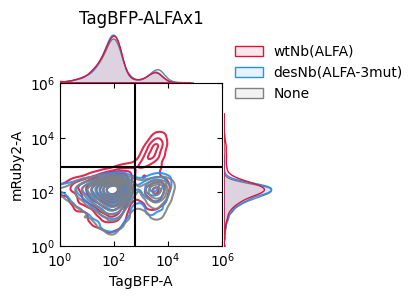

In [60]:
# Just look at TagBFPx1 ALFA
Target = 'TagBFP-ALFAx1'
small_data = df[df.Target == Target]
small_data = small_data.groupby('Nb').sample(n=10000) # Downsample

# General plotting params
x = "TagBFP-A"
y = "mRuby2-A"
hue = "Nb"
hue_order = ['wtNb(ALFA)', 'desNb(ALFA-3mut)', 'None']

# Conditions
palette = {
    'wtNb(ALFA)': 'crimson',
    'desNb(ALFA-3mut)': 'dodgerblue',
    'None': 'grey'
}

# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = mRuby2_lim
xlim = TagBFP_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=True,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)

h,l = ax_histx.get_legend_handles_labels()
sns.move_legend(ax_histx, handles=h, labels=l,
    title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Threshold
ax_scatter.axvline(TagBFP_A_thresh, 0, 1, color='black')
ax_scatter.axhline(mRuby2_A_thresh, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing
ax_histx.set_title(Target) # Add plot label
# plt.savefig(figpath + f'joint_TagBFP-v-mRuby2_{Target}.svg', bbox_inches='tight')

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)
/var/folders/2d/h4qyrjcd68x7g4p2qdv30s8h0000gn/T/ipykernel_59494/3897367881.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


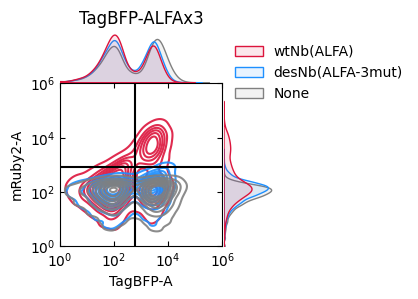

In [ ]:
# Just look at TagBFPx3 ALFA
Target = 'TagBFP-ALFAx3'
small_data = df[df.Target == Target]
small_data = small_data.groupby('Nb').sample(n=10000) # Downsample

# General plotting params
x = "TagBFP-A"
y = "mRuby2-A"
hue = "Nb"
hue_order = ['wtNb(ALFA)', 'desNb(ALFA-3mut)', 'None']

# Conditions
palette = {
    'wtNb(ALFA)': 'crimson',
    'desNb(ALFA-3mut)': 'dodgerblue',
    'None': 'grey'
}


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(2.5, 2.5))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
ylim = mRuby2_lim
xlim = TagBFP_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=True,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette, 
    log_scale=True, fill=True, common_norm=False, legend=False,
)

h,l = ax_histx.get_legend_handles_labels()
sns.move_legend(ax_histx, handles=h, labels=l,
    title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)

# Threshold
ax_scatter.axvline(TagBFP_A_thresh, 0, 1, color='black')
ax_scatter.axhline(mRuby2_A_thresh, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing
ax_histx.set_title(Target) # Add plot label
# plt.savefig(figpath + f'joint_TagBFP-v-mRuby2_{Target}.svg', bbox_inches='tight')

## Plot percentages of mRuby2 and TagBFP across ALFA conditions

In [67]:
# Categorize cells based on TagBFP and mRuby2 levels
df['TagBFP_cat'] = np.where(df['TagBFP-A'] > TagBFP_A_thresh, 'TagBFP+', 'TagBFP-') 
df['mRuby2_cat'] = np.where(df['mRuby2-A'] > mRuby2_A_thresh, 'mRuby2+', 'mRuby2-') 

In [107]:
# Get only mRuby2+
mRuby2_df = df.loc[df['mRuby2_cat'] == 'mRuby2+'] 

# Calculate mRuby2+ populations using these metrics
well_group = ['Target', 'Nb', 'well']
count_df = mRuby2_df.groupby([*well_group, 'TagBFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if none rather than dropping row
mRuby2_percent_df = (count_df*100/count_df.groupby(well_group
                           ).transform('sum')).reset_index(name='percent')

# Merge percent and count
mRuby2_count_df = count_df.reset_index()
mRuby2_df = pd.merge(mRuby2_count_df, mRuby2_percent_df)

In [113]:
# Get rid of wells with barely any mRuby2+
for well in mRuby2_df.well.unique():
    curr_well = mRuby2_df[mRuby2_df.well == well]
    cell_thresh = 20
    if np.sum(curr_well['count']) < cell_thresh:
        # mRuby2_df = mRuby2_df.loc[mRuby2_df.well != well]
        mRuby2_df.loc[(mRuby2_df.well == well) & (mRuby2_df.TagBFP_cat == "TagBFP+"), 'percent'] = 0

/Users/natwang/Documents/GitHub/desNb-circuit/env/lib/python3.9/site-packages/seaborn/utils.py:413: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  new_legend = legend_func(handles, labels, loc=loc, **props)


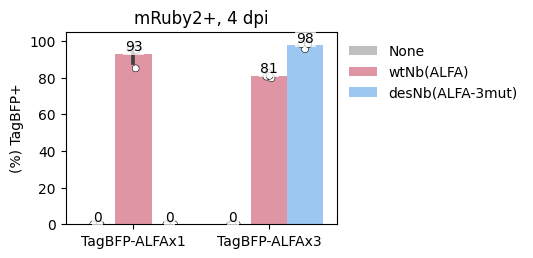

In [ ]:
# General plotting params
x = 'Target'
y = 'percent'
hue = 'Nb'
color = 'dogerblue'
hue_order = ['None', 'wtNb(ALFA)', 'desNb(ALFA-3mut)']
order = ['TagBFP-ALFAx1', 'TagBFP-ALFAx3']
palette = {'wtNb(ALFA)': 'crimson','desNb(ALFA-3mut)': 'dodgerblue', 'None': 'grey'}

fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5))
# Plot eGFP+ % of mRuby2+ cells
sns.barplot(
    ax=ax, data=mRuby2_df.loc[mRuby2_df.TagBFP_cat == 'TagBFP+'],
    x=x, y=y, hue=hue,
    order=order, hue_order=hue_order,
    alpha=0.5, palette=palette)

sns.stripplot(
    ax=ax, data=mRuby2_df.loc[mRuby2_df.TagBFP_cat == 'TagBFP+'],
    x=x, y=y, hue=hue,
    order=order, hue_order=hue_order,
    dodge=True,
    palette = {hue: 'white' for hue in hue_order},
    size=5, edgecolor='black', linewidth=0.4,)


# Add barplot labels
for i in ax.containers:
    bar_labels = ax.bar_label(i, fmt='%0.0f', padding=0)
    for label in bar_labels:
        label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))  
ax.set_ylim((0, 105))
h,l = ax.get_legend_handles_labels()
sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
    title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
ax.yaxis.set_label_text('(%) TagBFP+')
ax.set_title('mRuby2+, 4 dpi')
ax.set_xlabel('')
# plt.savefig(figpath + f'bar_selectivity.svg', bbox_inches='tight')
